In [24]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import  models, layers
from PIL import Image
import matplotlib.pyplot as plt

In [25]:
import tensorflow as tf
print(tf.keras.__version__)


3.13.2


In [26]:
import numpy as np
#simple function f(x) = X^2
def f(x):
  return x**2
#Manual derivative (f'(x) = 2x)
def gradient(x):
  return 2 * x
# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10):    #Manually optimize for 10 steps
  x -= learning_rate * gradient(x)
  print(f"x = {x}, f(x) = {f(x)}")



x = 4.0, f(x) = 16.0
x = 3.2, f(x) = 10.240000000000002
x = 2.56, f(x) = 6.5536
x = 2.048, f(x) = 4.194304
x = 1.6384, f(x) = 2.68435456
x = 1.31072, f(x) = 1.7179869184000003
x = 1.0485760000000002, f(x) = 1.0995116277760004
x = 0.8388608000000002, f(x) = 0.7036874417766403
x = 0.6710886400000001, f(x) = 0.45035996273704976
x = 0.5368709120000001, f(x) = 0.2882303761517119


In [27]:
import tensorflow as tf
x = tf.Variable(5.0) # trainable variable
with tf.GradientTape() as tape:
  y = x ** 2 # y = x^2
grad = tape.gradient(y,x) # Compute dy/dx automatically
print(grad.numpy())

10.0


In [28]:
import numpy as np
import tensorflow as tf
import time
#Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
#Numpy multiplication
start = time.time()
C_numpy = np.dot(A,B)
print("NumPy Time:", time.time() - start)
#TensorFlow Multiplication (for colab uses GPU Runtime if availabale)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.06984186172485352
TensorFlow Time: 0.1341090202331543


In [29]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

In [57]:
import numpy as np

# Ensure x_train is flattened for this manual linear model
x_train_flat = x_train.reshape(x_train.shape[0], -1)

weights = np.random.rand(x_train_flat.shape[1], y_train.shape[1])

learning_rate = 0.01

for epoch in range(10):
# Forward pass
   y_pred = np.dot(x_train_flat, weights)
# Compute loss using the one-hot encoded y_train
   loss = np.mean((y_pred - y_train) ** 2)
# Compute gradients manually
   gradients = 2 * np.dot(x_train_flat.T, (y_pred - y_train)) / len(x_train_flat)
# Update weights
   weights -= learning_rate * gradients
   print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 2891.1069536798636
Epoch 1, Loss: 198.88455303591297
Epoch 2, Loss: 42.4863423253323
Epoch 3, Loss: 30.468353480519397
Epoch 4, Loss: 27.08403242133231
Epoch 5, Loss: 24.563710246914965
Epoch 6, Loss: 22.408865365819175
Epoch 7, Loss: 20.54276933307615
Epoch 8, Loss: 18.920400218006986
Epoch 9, Loss: 17.50503765800933


In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
   Input(shape=(784,)),
   Dense(64, activation='relu'),
   Dense(10, activation='softmax')
])

In [64]:
import numpy as np

# Dummy data (example only)
x_train = np.random.rand(100, 3)
y_train = np.random.rand(100, 3)

weights = np.random.rand(3, 3)
learning_rate = 0.01

for epoch in range(10):
    y_pred = np.dot(x_train, weights)

    loss = np.mean((y_pred - y_train) ** 2)

    gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)

    weights -= learning_rate * gradients

    print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.23529128898441978
Epoch 1, Loss: 0.2320724140904044
Epoch 2, Loss: 0.2289513765386969
Epoch 3, Loss: 0.22592513535183165
Epoch 4, Loss: 0.22299074430766855
Epoch 5, Loss: 0.2201453489860524
Epoch 6, Loss: 0.21738618390752384
Epoch 7, Loss: 0.21471056976121475
Epoch 8, Loss: 0.21211591071914707
Epoch 9, Loss: 0.20959969183424235


In [65]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100): # Training loop
     gradient = np.random.randn(3, 3) # Fake gradient for illustration
     weights -= learning_rate * gradient

In [66]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

In [67]:
from tensorflow.keras.layers import Dense

units = 64
layer = Dense(units, activation=None, use_bias=True, kernel_initializer="glorot_uniform")

In [68]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid")

Training set: (13323, 28, 28, 1), Labels: (13323, 10)
Testing set: (3015, 28, 28, 1), Labels: (3015, 10)


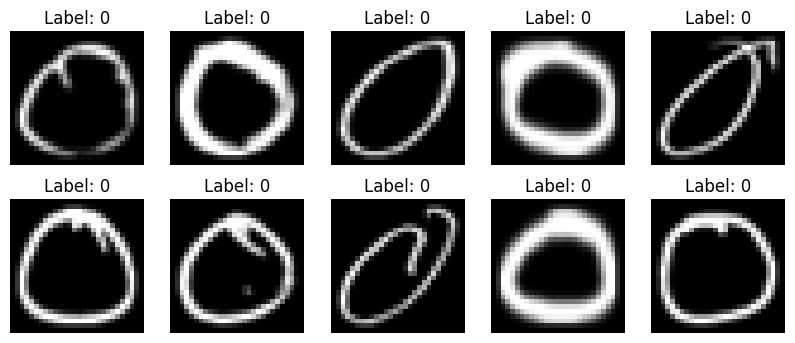

In [35]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow
# Define dataset paths
train_dir = "/content/drive/MyDrive/AiMl/Data/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AiMl/Data/DevanagariHandwrittenDigitDataset/Test"
# Define image size
img_height, img_width = 28, 28
# Function to load images and labels using PIL
def load_images_from_folder(folder):
   images = []
   labels = []
   class_names = sorted(os.listdir(folder))
   class_map = {name: i for i, name in enumerate(class_names)}
   for class_name in class_names:
       class_path = os.path.join(folder, class_name)
       label = class_map[class_name]
       for filename in os.listdir(class_path):
           img_path = os.path.join(class_path, filename)
     # Load image using PIL
           img = Image.open(img_path).convert("L")
           img = img.resize((img_width, img_height))
           img = np.array(img) / 255.0
           images.append(img)
           labels.append(label)
   return np.array(images), np.array(labels)
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

In [36]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
# Use with Cautions.

In [37]:
x_train = x_train.reshape(-1, img_height, img_width, 3)
# Use with Cautions.

Loading and processing MNIST Handwritten Digit Dataset:

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)
# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [39]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
   [
       keras.layers.Input(shape=input_shape),
       keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
       keras.layers.Dense(64, activation="sigmoid"),
       keras.layers.Dense(128, activation="sigmoid"),
       keras.layers.Dense(256, activation="sigmoid"),
       keras.layers.Dense(num_classes, activation="softmax"),
]
)

In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
def build_functional_model():
  # Input layer
    inputs = keras.Input(shape=input_shape)
    # Flatten layer
    x = keras.layers.Flatten()(inputs)
    # Hidden layers
    x = keras.layers.Dense(64, activation="sigmoid")(x)
    x = keras.layers.Dense(128, activation="sigmoid")(x)
    x = keras.layers.Dense(256, activation="sigmoid")(x)
    # Output layer
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model
#Build the model
functional_model = build_functional_model()
functional_model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compiling and Training the model

In [42]:
model.compile(
    optimizer="sgd", # Stochastic Gradient Descent
    loss="categorical_crossentropy", # Loss function for multi-class classification
    metrics=["accuracy"]
)

In [82]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label for first image: 2
True label for first image: 7


In [83]:
model.save('mnist_fully_connected_model.h5')

In [84]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

Task1: Data Preparation

In [85]:

def load_devnagari_data(folder_path):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder_path))

    for label_index, folder_name in enumerate(class_names):
        full_path = os.path.join(folder_path, folder_name)
        if not os.path.isdir(full_path): continue

        for filename in os.listdir(full_path):
            img_path = os.path.join(full_path, filename)

            img = Image.open(img_path).convert('L')
            img = img.resize((28, 28))

            images.append(np.array(img) / 255.0)
            labels.append(label_index)

    return np.array(images), np.array(labels)

# Load the data
x_train, y_train = load_devnagari_data("/content/drive/MyDrive/AiMl/Data/DevanagariHandwrittenDigitDataset/Train")
x_test, y_test = load_devnagari_data("/content/drive/MyDrive/AiMl/Data/DevanagariHandwrittenDigitDataset/Test")

# Convert labels to One-Hot Encoding
y_train_hot = tf.keras.utils.to_categorical(y_train, 10)
y_test_hot = tf.keras.utils.to_categorical(y_test, 10)

print(f"Task 1 Complete: Loaded {len(x_train)} training images.")

Task 1 Complete: Loaded 13323 training images.


Task 2: Build the FCN Model

In [86]:
# Create Sequential Model
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(256, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

Task 3: Compile the Model

In [87]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Loss function for one-hot labels
    metrics=['accuracy']             # Evaluation metric
)

model.summary() # Displays the model structure

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 4: Train the Model

In [88]:
# Training the model
history = model.fit(
    x_train,
    y_train_hot,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4755 - loss: 1.5591 - val_accuracy: 0.0000e+00 - val_loss: 5.3818
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8007 - loss: 0.5898 - val_accuracy: 0.1932 - val_loss: 5.9433
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9146 - loss: 0.3162 - val_accuracy: 0.2841 - val_loss: 6.2671
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9416 - loss: 0.2036 - val_accuracy: 0.3006 - val_loss: 6.5390
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9546 - loss: 0.1534 - val_accuracy: 0.3302 - val_loss: 6.6082
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9644 - loss: 0.1232 - val_accuracy: 0.3265 - val_loss: 6.7676
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9719 - loss: 0.0994 - val_accuracy: 0.3283 - val_loss: 6.8662
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9760 - loss: 0.0852 - val_accuracy: 0.3392 - val_

Task 5: Evaluate the Model

In [89]:
# Evaluate performance
test_loss, test_acc = model.evaluate(x_test, y_test_hot, verbose=1)

print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6819 - loss: 3.7598

Test Accuracy: 68.19%
Test Loss: 3.7598


Task 6: Save and Load the Model

In [90]:
# Task 6: Saving
model.save("devnagari_digit_model.keras")
print("Model saved as devnagari_digit_model.keras")

# Task 6: Loading (cleanly)
loaded_model = tf.keras.models.load_model("devnagari_digit_model.keras", compile=False)
# Re-compile to allow evaluation
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Verification
val_loss, val_acc = loaded_model.evaluate(x_test, y_test_hot, verbose=0)
print(f"Loaded Model Verified Accuracy: {val_acc * 100:.2f}%")

Model saved as devnagari_digit_model.keras
Loaded Model Verified Accuracy: 68.19%


Task 7: Predictions

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


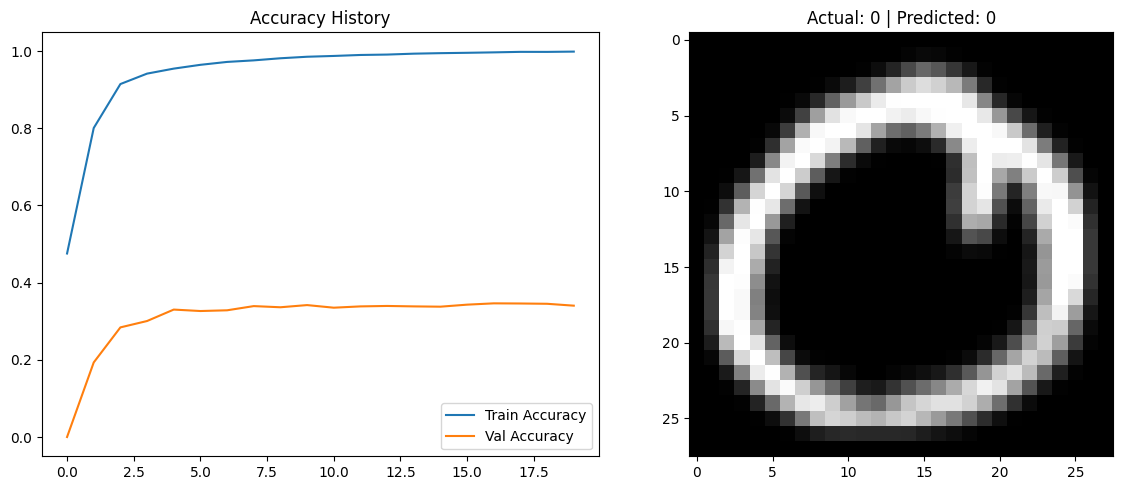

In [91]:

predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Visualization for Deliverables
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy History')
plt.legend()

# Display a sample prediction
plt.subplot(1, 2, 2)
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Actual: {y_test[0]} | Predicted: {predicted_labels[0]}")

plt.tight_layout()
plt.show()